In [156]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import pandas as pd
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import ROOT as root
from ROOT import TFile, TTree, TList
from scipy.optimize import curve_fit
import sympy as sp

In [157]:
cGy = 1e2 # cGy -> Gy

In [158]:
dataset1="DetRotX0deg/angles/dose/*"

In [159]:
filenames = [0, 45, 90, 135, 180, 225, 270, 315]
mean_dose = []
mean_dose1 = []
mean_dose2 = []
dose_grid = []

df10x10 = pd.DataFrame()

for z in filenames:
     print(str(z),"cm data processing ...")
     pathList = glob.glob(dataset1+"/"+str(z)+"/*/2Dmap20cm.out")
     print(pathList)
     df10x10 = pd.DataFrame()
     
     for filename in pathList:
        temp_df = pd.read_csv(filename, sep=",", header=None, skiprows=4, 
                               names=["iX", "iY", "iZ", "dose", "dose^2", "entries"])
        df10x10 = df10x10.add(temp_df, fill_value=0)
        
     if not df10x10.empty:
        df10x10 /= len(pathList)
        dose_pivot = df10x10.pivot(index='iX', columns='iY', values='dose') * cGy
        dose_grid.append(dose_pivot)
        mean_dose.append(np.mean(dose_grid[-1].values))
        mean_dose1.append(np.mean(dose_pivot,1))
        mean_dose2.append(np.mean(dose_pivot,0))


0 cm data processing ...
['DetRotX0deg/angles/dose/20241014_134900/0/9/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/11/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/7/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/6/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/1/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/10/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/8/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/4/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/3/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/12/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/2/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241014_134900/0/5/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241016_101241/0/9/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241016_101241/0/11/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241016_101241/0/7/2Dmap20cm.out', 'DetRotX0deg/angles/dose/20241016_101241/0/6/2Dmap20cm.

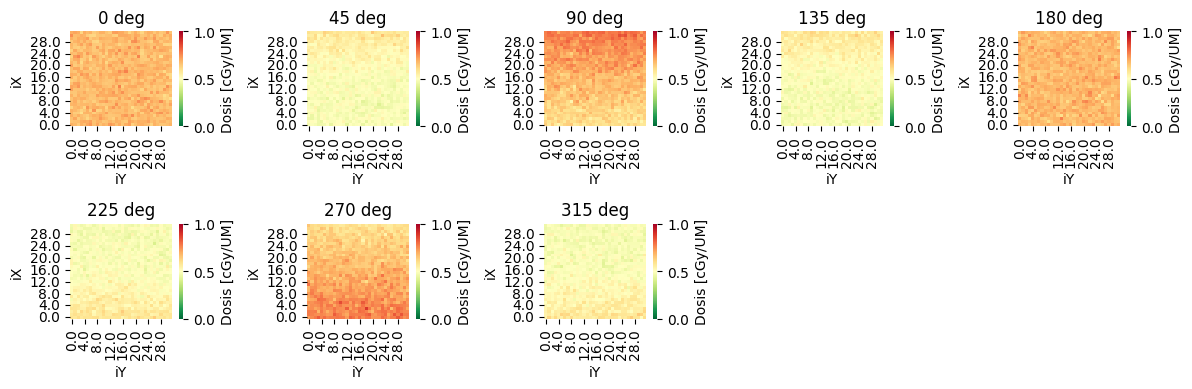

In [160]:
fig=plt.figure(figsize=(12,4))

i = 0
for data in dose_grid:
    ax1=fig.add_subplot(2,5,i+1)
    ax1.set_title(str(filenames[i]) + ' deg')
    cbar_kws = { 'label': 'Dosis [cGy/UM]'}
    ax1 = sns.heatmap(data=data, cmap='RdYlGn_r', cbar=True, cbar_kws=cbar_kws, vmin=0, vmax=1)
    ax1.invert_yaxis()
    i=i+1

fig.tight_layout()
plt.show()

In [161]:
dose = np.array(mean_dose) # cGy
print("Dosis absorbida en agua:",dose,"cGy/UM")

Dosis absorbida en agua: [0.6757042  0.50799954 0.68384974 0.50800178 0.67747775 0.50938563
 0.68437489 0.50685681] cGy/UM


In [162]:
nC = 1e9  # nC -> C
nofEvents = 1000e6 
nofEvents = 100e6    
fScaleFactorMU = 1/2.3514811546434146e-13
fSimulatedMU = 1
scale_factor = (1./nofEvents)*fScaleFactorMU*fSimulatedMU

In [163]:
print(scale_factor) # 4252.64

42526.388018263446


In [164]:
dataset2="DetRotX0deg/angles/charge/*"

In [140]:
SensorReadout1 = np.zeros([32,24,np.size(filenames)])
SensorReadout2 = np.zeros([32,24,np.size(filenames)])
mean_charge1 = []
mean_charge2 = []

k=0
for z in filenames:
     print(str(z),"deg data processing ...")
     pathList = glob.glob(dataset2+"/"+ str(z) +"/*/BB7Readout.root")
     print(pathList)

     j=0
     for path in pathList:
          print("File",str(j),"is being read ...")
          f = root.TFile(path)
          myTree = f.Get("BB7Hits")
          entries = myTree.GetEntriesFast()

          for entry in myTree:
               stripID = int(entry.StripID)
               if(entry.SensorID==0):
                    SensorReadout1[stripID,j,k] += myTree.GetLeaf('Charge[coulomb]').GetValue()*scale_factor*nC
               if(entry.SensorID==1):
                    SensorReadout2[stripID,j,k] += myTree.GetLeaf('Charge[coulomb]').GetValue()*scale_factor*nC
          j=j+1
     mean_charge1.append(np.mean(SensorReadout1[:,:,k],1))
     mean_charge2.append(np.mean(SensorReadout2[:,:,k],1))
     k=k+1

0 deg data processing ...
['DetRotX0deg/angles/charge/20241015_174249/0/9/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/11/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/7/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/6/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/1/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/10/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/8/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/4/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/3/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/12/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/2/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_174249/0/5/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_090910/0/9/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_090910/0/11/BB7Readout.root', 'DetRotX0deg/angles/charge/20241015_090910/0/7/BB7Readout.r

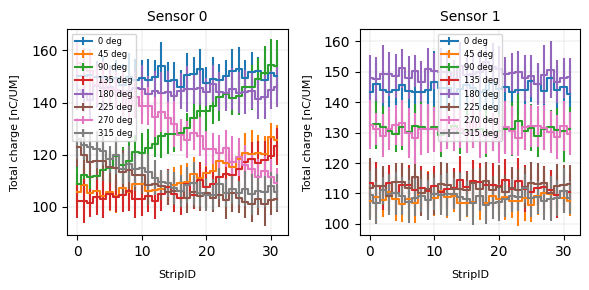

In [165]:
fig=plt.figure(figsize=(6,3))

x=np.linspace(0, 31, 32)

ax1=fig.add_subplot(121)
ax1.set_title('Sensor 0', fontsize=10)
ax1.set_xlabel('StripID', fontsize=8,labelpad=8)
ax1.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax1.set_ylim([0, 200])
ax1.grid(linestyle='--', linewidth=0.25)

k=0
for z in filenames:
    ax1.errorbar(x,np.mean(SensorReadout1[:,:,k],1),yerr=np.std(SensorReadout1[:,:,k],1), ds='steps-mid', label=str(z) + ' deg')
    k=k+1


ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(122)
ax2.set_title('Sensor 1', fontsize=10)
ax2.set_xlabel('StripID', fontsize=8,labelpad=8)
ax2.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax2.set_ylim([0, 200])
ax2.grid(linestyle='--', linewidth=0.25)

k=0
for z in filenames:
    ax2.errorbar(x,np.mean(SensorReadout2[:,:,k],1),yerr=np.std(SensorReadout2[:,:,k],1), ds='steps-mid', label=str(z) + ' deg')
    k=k+1

ax2.legend(loc='best', fontsize="6")

fig.tight_layout()
plt.show()

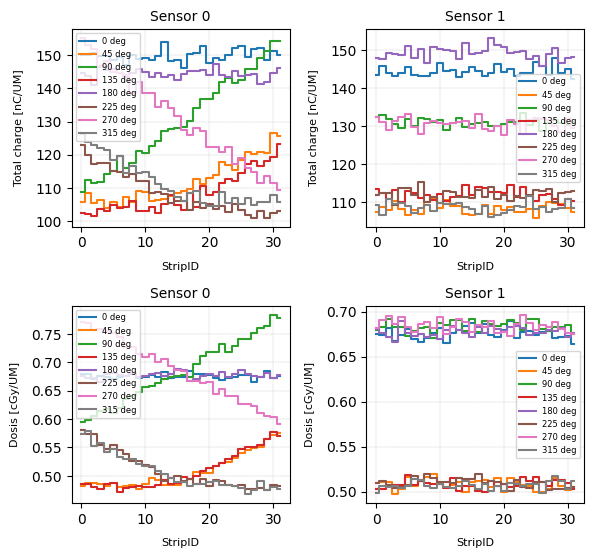

In [166]:
fig=plt.figure(figsize=(6,8))

x=np.linspace(0, 31, 32)

ax1=fig.add_subplot(321)
ax1.set_title('Sensor 0', fontsize=10)
ax1.set_xlabel('StripID', fontsize=8,labelpad=8)
ax1.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax1.set_ylim([0, 200])
ax1.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax1.errorbar(x,np.array(mean_charge1[i]), ds='steps-mid', label=str(label) + ' deg')
    k=k+1


ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(322)
ax2.set_title('Sensor 1', fontsize=10)
ax2.set_xlabel('StripID', fontsize=8,labelpad=8)
ax2.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax2.set_ylim([0, 200])
ax2.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax2.errorbar(x,np.array(mean_charge2[i]), ds='steps-mid', label=str(label) + ' deg')
    k=k+1

ax2.legend(loc='best', fontsize="6")

ax3=fig.add_subplot(323)
ax3.set_title('Sensor 0', fontsize=10)
ax3.set_xlabel('StripID', fontsize=8,labelpad=8)
ax3.set_ylabel('Dosis [cGy/UM]', fontsize=8,labelpad=8)
#ax3.set_ylim([0, 200])
ax3.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax3.errorbar(x,np.array(mean_dose1[i]), ds='steps-mid', label=str(label) + ' deg')
    k=k+1


ax3.legend(loc='best', fontsize="6")

ax4=fig.add_subplot(324)
ax4.set_title('Sensor 1', fontsize=10)
ax4.set_xlabel('StripID', fontsize=8,labelpad=8)
ax4.set_ylabel('Dosis [cGy/UM]', fontsize=8,labelpad=8)
#ax4.set_ylim([0, 200])
ax4.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax4.errorbar(x,np.array(mean_dose2[i]), ds='steps-mid', label=str(label) + ' deg')
    k=k+1

ax4.legend(loc='best', fontsize="6")

fig.tight_layout()
plt.show()

In [167]:
charge1 = np.array(mean_charge1) # nC
print("Carga promedio por strip (Sensor1):",charge1,"nC/UM")

charge2 = np.array(mean_charge2) # nC
print("Carga promedio por strip (Sensor2):",charge2,"nC/UM")

dose1 = np.array(mean_dose1) # cGy
print("Dosis absorbda en agua por posición de strip (Sensor1):",dose1,"cGy/UM")

dose2 = np.array(mean_dose2) # cGy
print("Dosis absorbda en agua por posición de strip (Sensor2):",dose2,"cGy/UM")

Carga promedio por strip (Sensor1): [[150.05864331 150.15561841 150.74055952 149.66649469 149.74347166
  148.52625679 149.35401494 146.90808716 149.94978635 148.81015031
  149.25149366 148.49456645 149.65958951 154.12747126 148.2555658
  148.67901696 146.07726096 150.4551764  150.79481979 152.85659087
  147.5485019  149.11145908 148.70634043 150.16751134 152.0457523
  152.76453624 149.3131     151.78328859 152.16136766 148.7073917
  151.15610676 150.07289625]
 [105.78111244 108.33781659 105.45909438 106.22158963 104.08280239
  105.61011769 104.17349206 107.1962671  105.73590643 108.93860017
  108.69999868 106.03184816 106.32627589 106.7638247  107.51326305
  108.41120343 109.011476   109.65271744 112.64791209 111.06644865
  112.94994876 113.88458541 117.6969898  116.87030534 115.46073036
  118.36789969 120.82465408 120.21017939 120.68793937 120.44206619
  126.70205234 125.58371523]
 [108.74671558 112.25268548 111.53979151 111.63110262 114.0782591
  115.01038554 119.4752282  115.9032359

In [168]:
def lineal0(x, a):
    return a * x

In [169]:
def pow0(x, a, b):
    return a * x ** b

In [170]:
strips=np.linspace(0, 31, 32)

In [171]:
popt1=[]
pcov1=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(lineal0, charge1[:,stripID], dose1[:,stripID])
        popt1.append(popt_tmp)
        pcov1.append(pcov_tmp)
        print("Optimal parameters (a):", popt1[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a): [0.00476134]
Optimal parameters (a): [0.00477609]
Optimal parameters (a): [0.00477996]
Optimal parameters (a): [0.00476792]
Optimal parameters (a): [0.00476341]
Optimal parameters (a): [0.00479892]
Optimal parameters (a): [0.00474864]
Optimal parameters (a): [0.00479848]
Optimal parameters (a): [0.00478382]
Optimal parameters (a): [0.00473628]
Optimal parameters (a): [0.00475899]
Optimal parameters (a): [0.00481702]
Optimal parameters (a): [0.00480031]
Optimal parameters (a): [0.0047553]
Optimal parameters (a): [0.00476706]
Optimal parameters (a): [0.00480281]
Optimal parameters (a): [0.00483794]
Optimal parameters (a): [0.00475141]
Optimal parameters (a): [0.00474544]
Optimal parameters (a): [0.00475552]
Optimal parameters (a): [0.00483143]
Optimal parameters (a): [0.00478153]
Optimal parameters (a): [0.00477272]
Optimal parameters (a): [0.00474246]
Optimal parameters (a): [0.0047732]
Optimal parameters (a): [0.00478478]
Optimal parameters (a): [0.0047579]
Opti

In [172]:
popt2=[]
pcov2=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(lineal0, charge2[:,stripID], dose2[:,stripID])
        popt2.append(popt_tmp)
        pcov2.append(pcov_tmp)
        print("Optimal parameters (a):", popt2[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a): [0.0047554]
Optimal parameters (a): [0.0047702]
Optimal parameters (a): [0.00479184]
Optimal parameters (a): [0.00473745]
Optimal parameters (a): [0.00478614]
Optimal parameters (a): [0.00473997]
Optimal parameters (a): [0.00478511]
Optimal parameters (a): [0.00477552]
Optimal parameters (a): [0.00479627]
Optimal parameters (a): [0.00475869]
Optimal parameters (a): [0.00476698]
Optimal parameters (a): [0.00474253]
Optimal parameters (a): [0.00477966]
Optimal parameters (a): [0.00480362]
Optimal parameters (a): [0.00476631]
Optimal parameters (a): [0.00479999]
Optimal parameters (a): [0.00476527]
Optimal parameters (a): [0.00478445]
Optimal parameters (a): [0.00477845]
Optimal parameters (a): [0.00475917]
Optimal parameters (a): [0.00477345]
Optimal parameters (a): [0.00477755]
Optimal parameters (a): [0.00479454]
Optimal parameters (a): [0.00478726]
Optimal parameters (a): [0.00478103]
Optimal parameters (a): [0.00476844]
Optimal parameters (a): [0.00477077]
Opt

In [173]:
popt3=[]
pcov3=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(pow0, charge1[:,stripID], dose1[:,stripID])
        popt3.append(popt_tmp)
        pcov3.append(pcov_tmp)
        print("Optimal parameters (a, b):", popt3[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a, b): [0.00645023 0.93776615]
Optimal parameters (a, b): [0.00547765 0.97187416]
Optimal parameters (a, b): [0.00714523 0.9173353 ]
Optimal parameters (a, b): [0.00598016 0.95340925]
Optimal parameters (a, b): [0.00542117 0.97340201]
Optimal parameters (a, b): [0.00495535 0.99339358]
Optimal parameters (a, b): [0.00357443 1.05847106]
Optimal parameters (a, b): [0.00414142 1.03039071]
Optimal parameters (a, b): [0.00400755 1.03652334]
Optimal parameters (a, b): [0.00428043 1.02085535]
Optimal parameters (a, b): [0.0043189  1.02001772]
Optimal parameters (a, b): [0.00403394 1.03664781]
Optimal parameters (a, b): [0.00463704 1.00715185]
Optimal parameters (a, b): [0.00444872 1.01374097]
Optimal parameters (a, b): [0.00293765 1.10001897]
Optimal parameters (a, b): [0.00303767 1.09477207]
Optimal parameters (a, b): [0.00344836 1.07014701]
Optimal parameters (a, b): [0.00440201 1.01578757]
Optimal parameters (a, b): [0.00406724 1.03181608]
Optimal parameters (a, b): [0.0

In [174]:
popt4=[]
pcov4=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(pow0, charge2[:,stripID], dose2[:,stripID])
        popt4.append(popt_tmp)
        pcov4.append(pcov_tmp)
        print("Optimal parameters (a, b):", popt4[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a, b): [0.00259746 1.12469613]
Optimal parameters (a, b): [0.00368428 1.05325711]
Optimal parameters (a, b): [0.00361178 1.05831915]
Optimal parameters (a, b): [0.0034941  1.06279701]
Optimal parameters (a, b): [0.00267283 1.12016636]
Optimal parameters (a, b): [0.00487915 0.99404167]
Optimal parameters (a, b): [0.00467393 1.00485507]
Optimal parameters (a, b): [0.00549834 0.97092146]
Optimal parameters (a, b): [0.00356862 1.06103627]
Optimal parameters (a, b): [0.00486838 0.9953017 ]
Optimal parameters (a, b): [0.00479923 0.9986111 ]
Optimal parameters (a, b): [0.00401494 1.03434673]
Optimal parameters (a, b): [0.00358366 1.05937035]
Optimal parameters (a, b): [0.00255416 1.13032867]
Optimal parameters (a, b): [0.00453356 1.01031839]
Optimal parameters (a, b): [0.00449715 1.01344838]
Optimal parameters (a, b): [0.00370265 1.05200516]
Optimal parameters (a, b): [0.00328096 1.07781267]
Optimal parameters (a, b): [0.0054337  0.97350694]
Optimal parameters (a, b): [0.0

In [175]:
charge1[:,stripID]

array([150.07289625, 125.58371523, 154.19657157, 123.24859023,
       146.00297246, 103.02487329, 109.2513394 , 105.82548436])

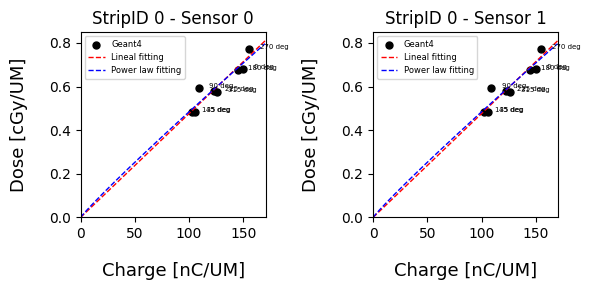

In [176]:
charge1_max=int(np.max(charge1[:])*1.1)
x1=np.linspace(0, charge1_max, charge1_max)

fig=plt.figure(figsize=(6,3))

ax1=fig.add_subplot(121)
ax1.set_title("StripID 0 - Sensor 0")
ax1.set_xlim([0, np.max(charge1[:,0])*1.1])
ax1.set_ylim([0, np.max(dose1[:,0])*1.1])
ax1.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax1.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax1.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax1.annotate(str(label)+' deg', (charge1[:,0][i] + 10, dose1[:,0][i]),fontsize=5)
ax1.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax1.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(122)
ax2.set_title("StripID 0 - Sensor 1")
ax2.set_xlim([0, np.max(charge1[:,0])*1.1])
ax2.set_ylim([0, np.max(dose1[:,0])*1.1])
ax2.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax2.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax2.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax2.annotate(str(label)+' deg', (charge1[:,0][i] + 10, dose1[:,0][i]),fontsize=5)
ax2.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax2.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax2.legend(loc='best', fontsize="6")

fig.tight_layout()

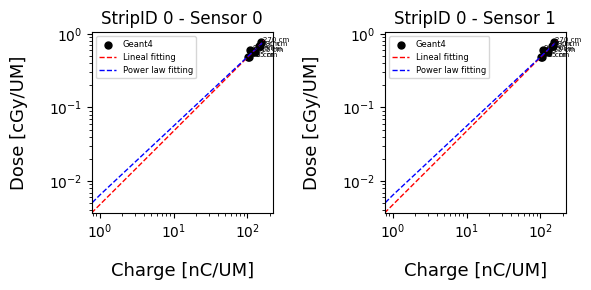

In [177]:
charge1_max=int(np.max(charge1[:])*1.1)
x1=np.linspace(0, charge1_max, charge1_max)

fig=plt.figure(figsize=(6,3))

ax1=fig.add_subplot(121)
ax1.set_title("StripID 0 - Sensor 0")
ax1.loglog()
#ax1.set_xlim([50, np.max(charge1[:,0])*1.1])
#ax1.set_ylim([0.4, np.max(dose1[:,0])*1.1])
ax1.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax1.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax1.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax1.annotate(str(label)+' cm', (charge1[:,0][i] + 10, dose1[:,0][i]),fontsize=5)
ax1.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax1.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(122)
ax2.loglog()
ax2.set_title("StripID 0 - Sensor 1")
#ax2.set_xlim([50, np.max(charge1[:,0])*1.1])
#ax2.set_ylim([0.4, np.max(dose1[:,0])*1.1])
ax2.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax2.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax2.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax2.annotate(str(label)+' cm', (charge1[:,0][i] + 5, dose1[:,0][i]),fontsize=5)
ax2.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax2.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax2.legend(loc='best', fontsize="6")

fig.tight_layout()

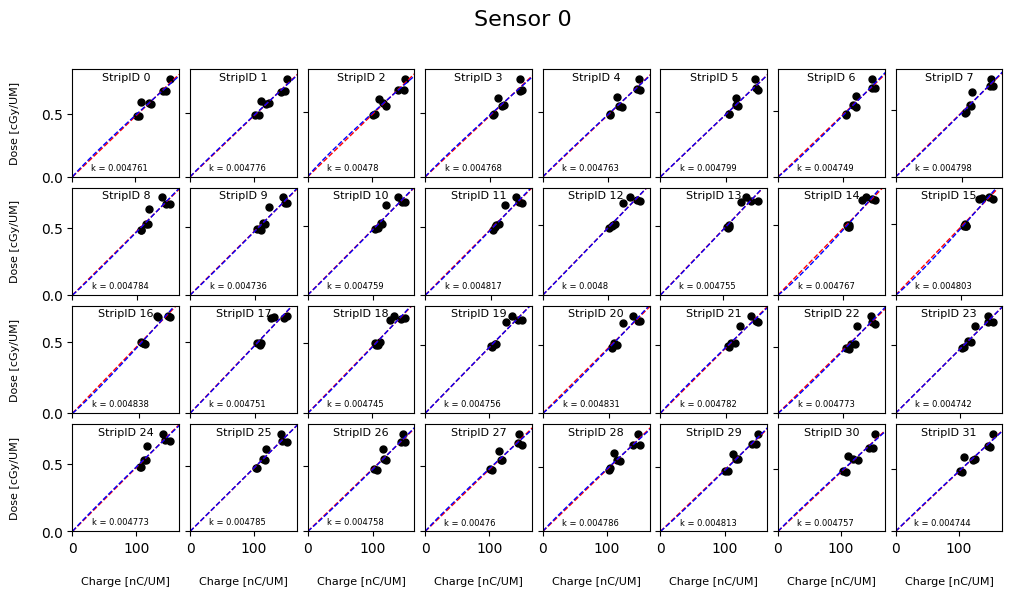

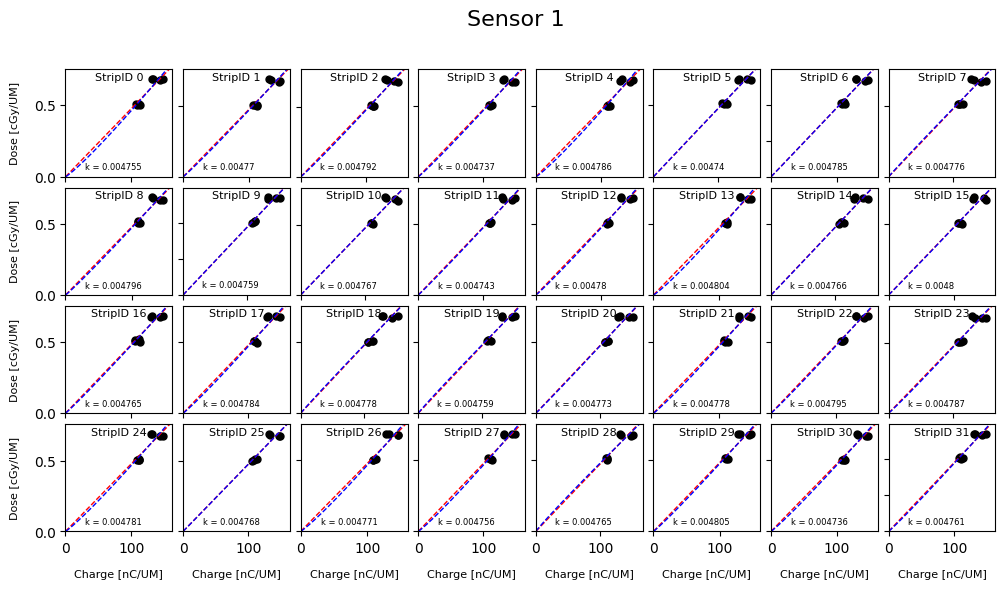

In [178]:
charge1_max=int(np.max(charge1[:])*1.1)
x1=np.linspace(0, charge1_max, charge1_max)

fig1=plt.figure(figsize=(12,6))
fig1.suptitle('Sensor 0', fontsize=16)

for stripID, value in enumerate(strips):
    ax1=fig1.add_subplot(4,8,stripID+1)
    ax1.set_xlim([0, np.max(charge1[:,stripID])*1.1])
    ax1.set_ylim([0, np.max(dose1[:,stripID])*1.1])
    ax1.set_title('StripID '+ str(stripID), fontsize=8, y=1.0, pad=-8)
    if(stripID>=24):
        ax1.set_xlabel('Charge [nC/UM]', fontsize=8,labelpad=15)
    else:
        ax1.set_xticklabels([])
    if(stripID%8==0):
        ax1.set_ylabel('Dose [cGy/UM]', fontsize=8,labelpad=15)
    else:
        ax1.set_yticklabels([])
    ax1.scatter(charge1[:,stripID],dose1[:,stripID],s=25, facecolors='black', edgecolors='black', label="Geant4")
    #for i, label in enumerate(filenames):
    #    ax1.annotate(str(label)+' cm', (charge1[:,stripID][i] + 10, dose[i]),fontsize=5)
    ax1.annotate("k = " + str(np.round(popt1[stripID][0],6)), (30, 0.05),fontsize=6)
    ax1.plot(x1, lineal0(x1, *popt1[stripID]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
    ax1.plot(x1, pow0(x1, *popt3[stripID]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

#ax1.legend(loc='best', fontsize="6")

fig1.subplots_adjust(wspace=0.1, hspace=0.1) #tight_layout()

charge2_max=int(np.max(charge2[:])*1.1)
x2=np.linspace(0, charge2_max, charge2_max)

fig2=plt.figure(figsize=(12,6))
fig2.suptitle('Sensor 1', fontsize=16)

for stripID, value in enumerate(strips):
    ax2=fig2.add_subplot(4,8,stripID+1)
    ax2.set_xlim([0, np.max(charge2[:,stripID])*1.1])
    ax2.set_ylim([0, np.max(dose2[:,stripID])*1.1])
    ax2.set_title('StripID '+ str(stripID), fontsize=8, y=1.0, pad=-8)
    if(stripID>=24):
        ax2.set_xlabel('Charge [nC/UM]', fontsize=8,labelpad=10)
    else:
        ax2.set_xticklabels([])
    if(stripID%8==0):
        ax2.set_ylabel('Dose [cGy/UM]', fontsize=8,labelpad=10)
    else:
        ax2.set_yticklabels([])
    ax2.scatter(charge2[:,stripID],dose2[:,stripID],s=25, facecolors='black', edgecolors='black', label="Geant4")
    #for i, label in enumerate(filenames):
    #    ax2.annotate(str(label)+' cm', (charge2[:,stripID][i] + 10, dose[i]),fontsize=5)
    ax2.annotate("k = " + str(np.round(popt2[stripID][0],6)), (30, 0.05),fontsize=6)
    ax2.plot(x2, lineal0(x2, *popt2[stripID]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
    ax2.plot(x2, pow0(x2, *popt4[stripID]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

#ax2.legend(loc='best', fontsize="6")

fig2.subplots_adjust(wspace=0.1, hspace=0.1) #tight_layout()


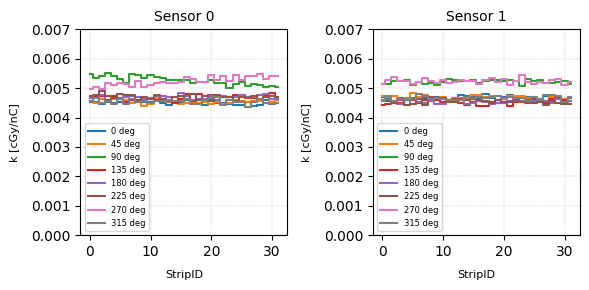

In [179]:
fig=plt.figure(figsize=(6,3))

x=np.linspace(0, 31, 32)

ax3=fig.add_subplot(121)
ax3.set_title('Sensor 0', fontsize=10)
ax3.set_xlabel('StripID', fontsize=8,labelpad=8)
ax3.set_ylabel('k [cGy/nC]', fontsize=8,labelpad=8)
ax3.set_ylim([0, 0.007])
ax3.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax3.errorbar(x,np.array(mean_dose1[i]/mean_charge1[i]), ds='steps-mid', label=str(label) + ' deg')
    k=k+1


ax3.legend(loc='best', fontsize="6")

ax4=fig.add_subplot(122)
ax4.set_title('Sensor 1', fontsize=10)
ax4.set_xlabel('StripID', fontsize=8,labelpad=8)
ax4.set_ylabel('k [cGy/nC]', fontsize=8,labelpad=8)
ax4.set_ylim([0, 0.007])
ax4.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax4.errorbar(x,np.array(mean_dose2[i]/mean_charge2[i]), ds='steps-mid', label=str(label) + ' deg')
    k=k+1

ax4.legend(loc='best', fontsize="6")

fig.tight_layout()
plt.show()